Loading the dataset in the form of _csv


In [2]:
import pandas as pd 
df = pd.read_csv('../data/raw/complaints.csv')
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_2640\3626014970.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [3]:
# check the shape , info and discriptionof the data 
print(df.shape)
df.info()
df.describe()

(9609797, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memo

,Complaint ID
count,9.609797e+06
mean,8.092744e+06
std,3.774842e+06
min,1.000000e+00
25%,5.038016e+06
50%,8.448508e+06
75%,1.129591e+07
max,1.423259e+07


['Credit reporting or other personal consumer reports' 'Debt collection'
 'Credit card' 'Checking or savings account'
 'Money transfer, virtual currency, or money service'
 'Vehicle loan or lease' 'Debt or credit management' 'Mortgage'
 'Payday loan, title loan, personal loan, or advance loan' 'Prepaid card'
 'Student loan' 'Credit reporting'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Payday loan, title loan, or personal loan'
 'Bank account or service' 'Money transfers' 'Consumer Loan' 'Payday loan'
 'Other financial service' 'Virtual currency']


<Axes: xlabel='Product'>

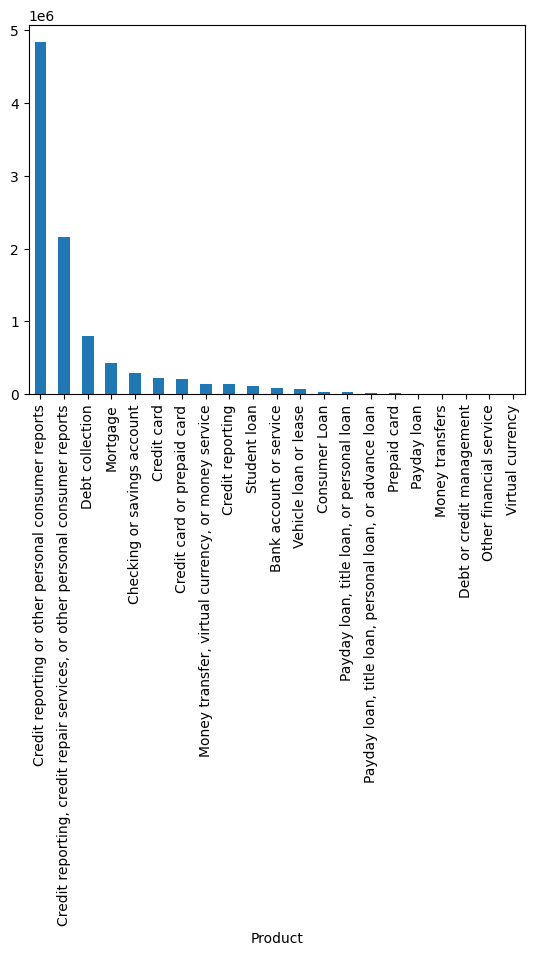

In [9]:
#distribution of complaints across different products
print(df['Product'].unique())
df['Product'].value_counts()
df['Product'].value_counts().plot(kind = 'bar')


In [10]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64


<Axes: ylabel='Frequency'>

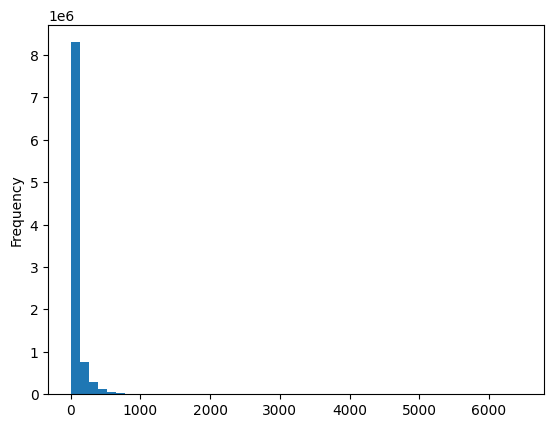

In [ ]:
# Complaints distribution across different states with narrative 
# length analysis 

df['narrative'] = df['Consumer complaint narrative'].fillna('')
df['word_count'] = df['narrative'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())
df['word_count'].plot(kind = 'hist', bins = 50)



In [15]:
with_text = df["Consumer complaint narrative"].notna().sum()
without_text = df["Consumer complaint narrative"].isna().sum()

print("With narrative:", with_text)
print("Without narrative:", without_text)

With narrative: 2980756
Without narrative: 6629041


In [ ]:
# working on the data with narrative on the specific products
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfers"
]

df = df[df["Product"].isin(products)]

In [ ]:
# dlete the rows with empty or null narratives
df = df[df["Consumer complaint narrative"].notna()]
df = df[df["Consumer complaint narrative"].str.strip() != ""]

In [ ]:
#cleaning the text data to improve the quality of the narratives 
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_narrative"] = df["Consumer complaint narrative"].apply(clean_text)

In [ ]:
# removing common boilerplate phrases that do not add value to the narrative
boilerplate_patterns = [
    r"i am writing to file a complaint",
    r"this is a complaint regarding",
]

def remove_boilerplate(text):
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)
    return text

df["cleaned_narrative"] = df["cleaned_narrative"].apply(remove_boilerplate)

In [ ]:
#saving the cleaned data to a new csv file for further analysis and modeling
df.to_csv('../data/processed/cleaned_complaints.csv', index=False)
print("saved the cleaned data to cleaned_complaints.csv" , "with shape:", df.shape)

saved the cleaned data to cleaned_complaints.csv with shape: (82164, 21)
